/tmp/ipykernel_1404/4198099474.py:23: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/4198099474.py:23: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/4198099474.py:23: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/4198099474.py:23: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/4198099474.py:23: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/4198099474.py:23: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_


PDR (LoRa_NS_DER) 

--- Pure Aloha – Unconfirmed ---
   N    value
  20 0.977818
  50 0.908021
 100 0.833616
 200 0.706539
 400 0.497973
 600 0.358697
 800 0.257232
1000 0.186959

--- Pure Aloha – Confirmed ---
   N    value
  20 0.829004
  50 0.651671
 100 0.489669
 200 0.320167
 400 0.185627
 600 0.128960
 800 0.094964
1000 0.072914

--- CSMA – Unconfirmed ---
   N    value
  20 0.978961
  50 0.918495
 100 0.855099
 200 0.731630
 400 0.544878
 600 0.411456
 800 0.309569
1000 0.233248

--- CSMA – Confirmed ---
   N    value
  20 0.838203
  50 0.652107
 100 0.489023
 200 0.323521
 400 0.187100
 600 0.126358
 800 0.092836
1000 0.070083

Énergie moyenne par nœud

--- Pure Aloha – Unconfirmed ---
   N      value
  20 0.162114 J
  50 0.160675 J
 100 0.163026 J
 200 0.162123 J
 400  0.16375 J
 600 0.162895 J
 800 0.162789 J
1000 0.163625 J

--- Pure Aloha – Confirmed ---
   N      value
  20 0.239384 J
  50 0.262681 J
 100   0.2901 J
 200 0.313024 J
 400 0.335836 J
 600 0.342322 J
 800 0.3

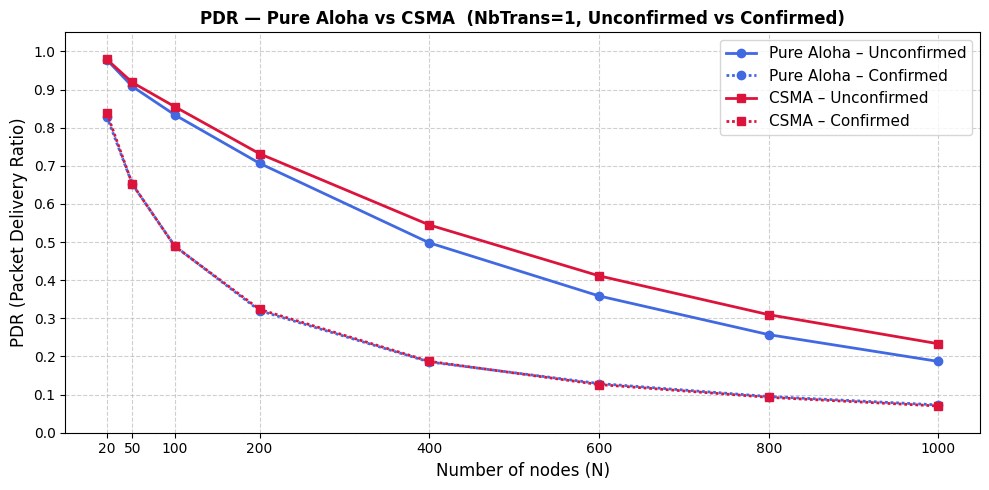

[OK] pdr_aloha_vs_csma.png sauvegardé


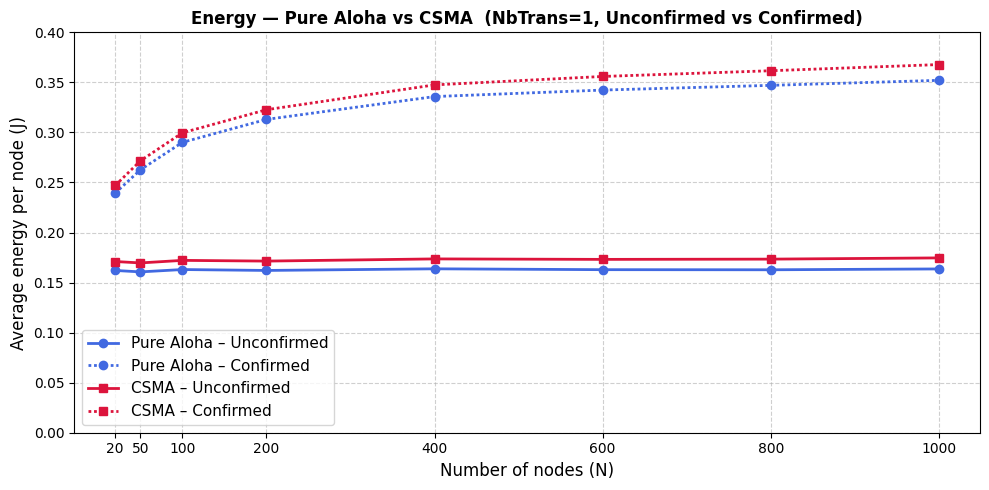

[OK] energy_aloha_vs_csma.png sauvegardé


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

# ── Chemins ──────────────────────────────────────────────────────────────────
PATHS = {
    "aloha": {
        "unconf": os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "conf":   os.path.join(BASE, "purealohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "unconf": os.path.join(BASE, "CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "conf":   os.path.join(BASE, "CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Helpers ───────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df


def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))


def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]]
              .copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_energy_per_node(csv_path, with_csma_energy=False):
    """
    Calcule l'énergie moyenne par nœud actif.
    Si with_csma_energy=True, ajoute 'Total CSMA Energy (J)' (pour CSMA).
    """
    df = _load(csv_path)
    N_dict = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
             df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    if sub_e.empty:
        print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                 df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})


def get_pdr_confirmed(csv_path):
    """PDR pour mode confirmé : receivedAckPackets / sentPackets."""
    ack  = get_results(csv_path, "receivedAckPackets")
    sent = get_results(csv_path, "sentPackets")
    if ack.empty or sent.empty:
        return ack
    merged = ack.merge(sent, on="N", suffixes=("_ack", "_sent"))
    out = merged[["N"]].copy()
    out["value"] = merged["value_ack"] / merged["value_sent"]
    return out


# ── Chargement des données ────────────────────────────────────────────────────
# PDR
pdr = {
    "aloha_unconf": None,
    "aloha_conf":   None,
    "csma_unconf":  None,
    "csma_conf":    None,
}

# Aloha unconfirmed
pdr["aloha_unconf"] = get_results(PATHS["aloha"]["unconf"], "LoRa_NS_DER", "networkServer")
if pdr["aloha_unconf"].empty:
    pdr["aloha_unconf"] = get_results(PATHS["aloha"]["unconf"], "LoRa_NS_DER")

# Aloha confirmed
pdr["aloha_conf"] = get_pdr_confirmed(PATHS["aloha"]["conf"])

# CSMA unconfirmed
pdr["csma_unconf"] = get_results(PATHS["csma"]["unconf"], "LoRa_NS_DER", "networkServer")
if pdr["csma_unconf"].empty:
    pdr["csma_unconf"] = get_results(PATHS["csma"]["unconf"], "LoRa_NS_DER")

# CSMA confirmed
pdr["csma_conf"] = get_pdr_confirmed(PATHS["csma"]["conf"])

# Énergie
energy = {
    "aloha_unconf": get_energy_per_node(PATHS["aloha"]["unconf"], with_csma_energy=False),
    "aloha_conf":   get_energy_per_node(PATHS["aloha"]["conf"],   with_csma_energy=False),
    "csma_unconf":  get_energy_per_node(PATHS["csma"]["unconf"],  with_csma_energy=True),
    "csma_conf":    get_energy_per_node(PATHS["csma"]["conf"],    with_csma_energy=True),
}

# ── Affichage des valeurs ─────────────────────────────────────────────────────
LABELS = {
    "aloha_unconf": "Pure Aloha – Unconfirmed",
    "aloha_conf":   "Pure Aloha – Confirmed",
    "csma_unconf":  "CSMA – Unconfirmed",
    "csma_conf":    "CSMA – Confirmed",
}

def print_table(data_dict, title, unit=""):
    print(f"\n{'='*65}")
    print(f"  {title}")
    print(f"{'='*65}")
    # Collecter tous les N présents
    all_N = sorted(set(
        n for df in data_dict.values()
        if df is not None and not df.empty
        for n in df["N"].tolist()
    ))
    # En-tête
    col_w = 22
    header = f"{'N':>6}" + "".join(f"{LABELS[k]:>{col_w}}" for k in data_dict)
    print(header)
    print("-" * len(header))
    # Lignes
    for n in all_N:
        row = f"{int(n):>6}"
        for k, df in data_dict.items():
            if df is not None and not df.empty:
                match = df[df["N"] == n]["value"]
                val = f"{match.values[0]:.4f} {unit}" if len(match) else "   —"
            else:
                val = "   —"
            row += f"{val:>{col_w}}"
        print(row)
    print(f"{'='*65}\n")

def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")

    for scenario, df in data_dict.items():
        print(f"\n--- {LABELS[scenario]} ---")

        if df.empty:
            print("Aucune donnée")
            continue

        display_df = df.copy()
        display_df["value"] = display_df["value"].round(6)

        if unit:
            display_df["value"] = display_df["value"].astype(str) + f" {unit}"

        print(display_df.to_string(index=False))
print_scenario_tables(
    pdr,
    "PDR (LoRa_NS_DER) "
)

print_scenario_tables(
    energy,
    "Énergie moyenne par nœud",
    unit="J"
)

# ── Style des courbes ─────────────────────────────────────────────────────────
CURVES = {
    "aloha_unconf": dict(color="royalblue",   marker="o", ls="-",        lw=2,   label="Pure Aloha – Unconfirmed"),
    "aloha_conf":   dict(color="royalblue",   marker="o", ls=(0,(1,1)),  lw=2,   label="Pure Aloha – Confirmed"),
    "csma_unconf":  dict(color="crimson",  marker="s", ls="-",        lw=2,   label="CSMA – Unconfirmed"),
    "csma_conf":    dict(color="crimson",  marker="s", ls=(0,(1,1)),  lw=2,   label="CSMA – Confirmed"),
}

# ── Figure 1 : PDR ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 5))
for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])

ax1.set_xlabel("Number of nodes (N)", fontsize=12)
ax1.set_ylabel("PDR (Packet Delivery Ratio)", fontsize=12)
ax1.set_title("PDR — Pure Aloha vs CSMA  (NbTrans=1, Unconfirmed vs Confirmed)",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_aloha_vs_csma.png", dpi=300)
plt.show()
print("[OK] pdr_aloha_vs_csma.png sauvegardé")

# ── Figure 2 : Énergie ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))
for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])

ax2.set_xlabel("Number of nodes (N)", fontsize=12)
ax2.set_ylabel("Average energy per node (J)", fontsize=12)
ax2.set_title("Energy — Pure Aloha vs CSMA  (NbTrans=1, Unconfirmed vs Confirmed)",
              fontsize=12, fontweight="bold")
ax2.set_ylim(0, 0.4)
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_aloha_vs_csma.png", dpi=300)
plt.show()
print("[OK] energy_aloha_vs_csma.png sauvegardé")

/tmp/ipykernel_1404/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_


PDR (LoRa_NS_DER) — Unconfirmed

--- Pure Aloha – NbTrans=1 ---
   N    value
  20 0.977818
  50 0.908021
 100 0.833616
 200 0.706539
 400 0.497973
 600 0.358697
 800 0.257232
1000 0.186959

--- Pure Aloha – NbTrans=3 ---
   N    value
  20 0.991368
  50 0.968981
 100 0.911150
 200 0.771340
 400 0.472922
 600 0.269964
 800 0.154487
1000 0.090989

--- Pure Aloha – NbTrans=8 ---
   N    value
  20 0.992922
  50 0.974699
 100 0.888141
 200 0.568104
 400 0.153470
 600 0.044103
 800 0.016304
1000 0.010005

--- CSMA – NbTrans=1 ---
   N    value
  20 0.978961
  50 0.918495
 100 0.855099
 200 0.731630
 400 0.544878
 600 0.411456
 800 0.309569
1000 0.233248

--- CSMA – NbTrans=3 ---
   N    value
  20 0.994593
  50 0.975040
 100 0.924137
 200 0.822177
 400 0.551484
 600 0.354536
 800 0.228242
1000 0.154359

--- CSMA – NbTrans=8 ---
   N    value
  20 0.996723
  50 0.985056
 100 0.916960
 200 0.673120
 400 0.252133
 600 0.096943
 800 0.043486
1000 0.022392

Énergie moyenne par nœud — Unconfirm

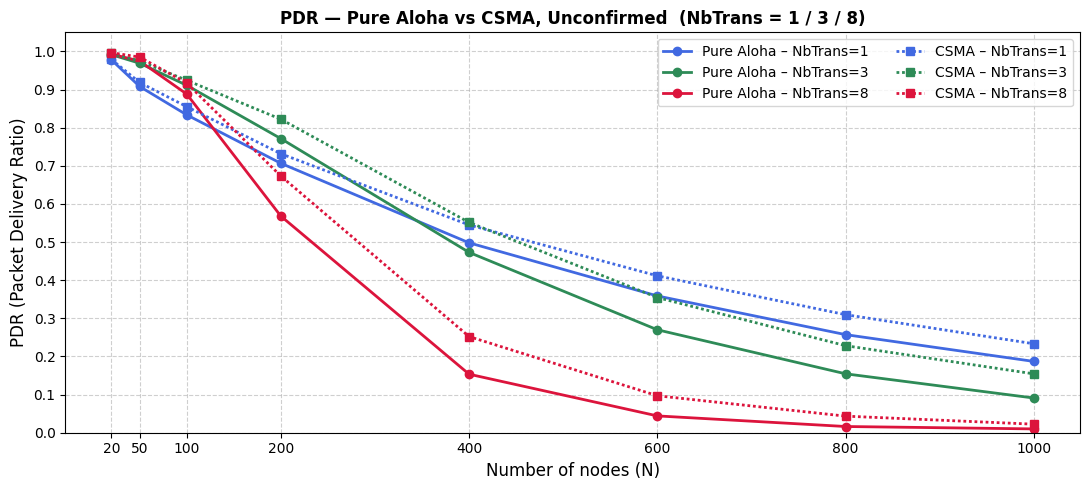

[OK] pdr_aloha_vs_csma_retx_unconf.png sauvegardé


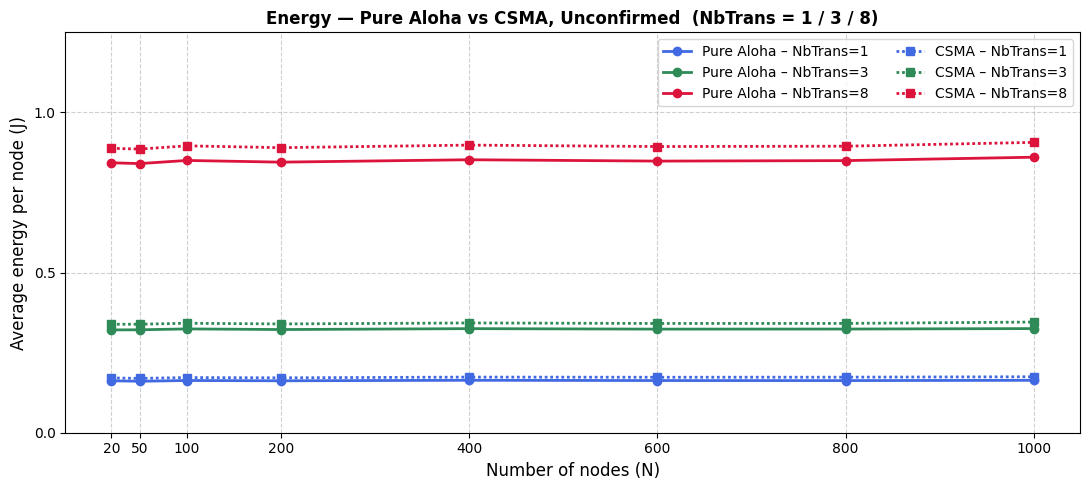

[OK] energy_aloha_vs_csma_retx_unconf.png sauvegardé


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

# ── Chemins ──────────────────────────────────────────────────────────────────
PATHS = {
    "aloha": {
        "0retx": os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "pureAlohaAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "0retx": os.path.join(BASE, "CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "CSMAAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Helpers ───────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df

def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))

def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]].copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")

def get_pdr_unconfirmed(csv_path):
    """PDR unconfirmed : LoRa_NS_DER depuis le networkServer."""
    der = get_results(csv_path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(csv_path, "LoRa_NS_DER")
    return der

def get_energy_per_node(csv_path, with_csma_energy=False):
    df = _load(csv_path)
    N_dict = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
              df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    if sub_e.empty:
        print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                  df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})

# ── Chargement PDR ────────────────────────────────────────────────────────────
pdr = {
    "aloha_0retx": get_pdr_unconfirmed(PATHS["aloha"]["0retx"]),
    "aloha_2retx": get_pdr_unconfirmed(PATHS["aloha"]["2retx"]),
    "aloha_7retx": get_pdr_unconfirmed(PATHS["aloha"]["7retx"]),
    "csma_0retx":  get_pdr_unconfirmed(PATHS["csma"]["0retx"]),
    "csma_2retx":  get_pdr_unconfirmed(PATHS["csma"]["2retx"]),
    "csma_7retx":  get_pdr_unconfirmed(PATHS["csma"]["7retx"]),
}

# ── Chargement Énergie ────────────────────────────────────────────────────────
energy = {
    "aloha_0retx": get_energy_per_node(PATHS["aloha"]["0retx"], with_csma_energy=False),
    "aloha_2retx": get_energy_per_node(PATHS["aloha"]["2retx"], with_csma_energy=False),
    "aloha_7retx": get_energy_per_node(PATHS["aloha"]["7retx"], with_csma_energy=False),
    "csma_0retx":  get_energy_per_node(PATHS["csma"]["0retx"],  with_csma_energy=True),
    "csma_2retx":  get_energy_per_node(PATHS["csma"]["2retx"],  with_csma_energy=True),
    "csma_7retx":  get_energy_per_node(PATHS["csma"]["7retx"],  with_csma_energy=True),
}

# ── Style des courbes ─────────────────────────────────────────────────────────
#   Couleur  → NbTrans   : bleu=1, orange=3, vert=8
#   Marqueur → protocole : o=Aloha, s=CSMA
#   Trait    → protocole : continu=Aloha, pointillé=CSMA
CURVES = {
    "aloha_0retx": dict(color="royalblue",   marker="o", ls="-",       lw=2, label="Pure Aloha – NbTrans=1"),
    "aloha_2retx": dict(color="seagreen",  marker="o", ls="-",       lw=2, label="Pure Aloha – NbTrans=3"),
    "aloha_7retx": dict(color="crimson",    marker="o", ls="-",       lw=2, label="Pure Aloha – NbTrans=8"),
    "csma_0retx":  dict(color="royalblue",   marker="s", ls=(0,(1,1)), lw=2, label="CSMA – NbTrans=1"),
    "csma_2retx":  dict(color="seagreen",  marker="s", ls=(0,(1,1)), lw=2, label="CSMA – NbTrans=3"),
    "csma_7retx":  dict(color="crimson",    marker="s", ls=(0,(1,1)), lw=2, label="CSMA – NbTrans=8"),
}

LABELS = {k: v["label"] for k, v in CURVES.items()}

# ── Affichage des valeurs ─────────────────────────────────────────────────────
def print_table(data_dict, title, unit=""):
    print(f"\n{'='*75}")
    print(f"  {title}")
    print(f"{'='*75}")
    all_N = sorted(set(
        n for df in data_dict.values()
        if df is not None and not df.empty
        for n in df["N"].tolist()
    ))
    col_w = 26
    header = f"{'N':>6}" + "".join(f"{LABELS[k]:>{col_w}}" for k in data_dict)
    print(header)
    print("-" * len(header))
    for n in all_N:
        row = f"{int(n):>6}"
        for k, df in data_dict.items():
            if df is not None and not df.empty:
                match = df[df["N"] == n]["value"]
                val = f"{match.values[0]:.4f}{' '+unit if unit else ''}" if len(match) else "—"
            else:
                val = "—"
            row += f"{val:>{col_w}}"
        print(row)
    print(f"{'='*75}\n")

def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")

    for scenario, df in data_dict.items():
        print(f"\n--- {LABELS[scenario]} ---")

        if df.empty:
            print("Aucune donnée")
            continue

        display_df = df.copy()
        display_df["value"] = display_df["value"].round(6)

        if unit:
            display_df["value"] = display_df["value"].astype(str) + f" {unit}"

        print(display_df.to_string(index=False))
print_scenario_tables(
    pdr,
    "PDR (LoRa_NS_DER) — Unconfirmed"
)

print_scenario_tables(
    energy,
    "Énergie moyenne par nœud — Unconfirmed",
    unit="J"
)

# ── Figure 1 : PDR ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 5))
for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])

ax1.set_xlabel("Number of nodes (N)", fontsize=12)
ax1.set_ylabel("PDR (Packet Delivery Ratio)", fontsize=12)
ax1.set_title("PDR — Pure Aloha vs CSMA, Unconfirmed  (NbTrans = 1 / 3 / 8)",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=10, ncol=2)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_aloha_vs_csma_retx_unconf.png", dpi=300)
plt.show()
print("[OK] pdr_aloha_vs_csma_retx_unconf.png sauvegardé")

# ── Figure 2 : Énergie ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 5))
for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])

ax2.set_xlabel("Number of nodes (N)", fontsize=12)
ax2.set_ylabel("Average energy per node (J)", fontsize=12)
ax2.set_title("Energy — Pure Aloha vs CSMA, Unconfirmed  (NbTrans = 1 / 3 / 8)",
              fontsize=12, fontweight="bold")
ax2.set_ylim(bottom=0, top=1.25)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=10, ncol=2)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_aloha_vs_csma_retx_unconf.png", dpi=300)
plt.show()
print("[OK] energy_aloha_vs_csma_retx_unconf.png sauvegardé")

/tmp/ipykernel_1404/1999041370.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/1999041370.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/1999041370.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/1999041370.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/1999041370.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/1999041370.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_


PDR (ACK/SentPackets) — Confirmed

--- Pure Aloha – NbTrans=1 ---
   N    value
  20 0.829004
  50 0.651671
 100 0.489669
 200 0.320167
 400 0.185627
 600 0.128960
 800 0.094964
1000 0.072914

--- Pure Aloha – NbTrans=3 ---
   N    value
  20 0.960163
  50 0.788174
 100 0.536519
 200 0.304957
 400 0.117350
 600 0.057795
 800 0.032586
1000 0.016493

--- Pure Aloha – NbTrans=8 ---
   N    value
  20 0.982114
  50 0.889539
 100 0.516570
 200 0.181192
 400 0.039752
 600 0.012356
 800 0.008454
1000 0.006193

--- CSMA – NbTrans=1 ---
   N    value
  20 0.838203
  50 0.652107
 100 0.489023
 200 0.323521
 400 0.187100
 600 0.126358
 800 0.092836
1000 0.070083

--- CSMA – NbTrans=3 ---
   N    value
  20 0.952846
  50 0.754386
 100 0.497630
 200 0.217799
 400 0.070807
 600 0.046193
 800 0.025016
1000 0.014293

--- CSMA – NbTrans=8 ---
   N    value
  20 0.968293
  50 0.753411
 100 0.346364
 200 0.094444
 400 0.019933
 600 0.013455
 800 0.007246
1000 0.002859

Énergie moyenne par nœud — Confirm

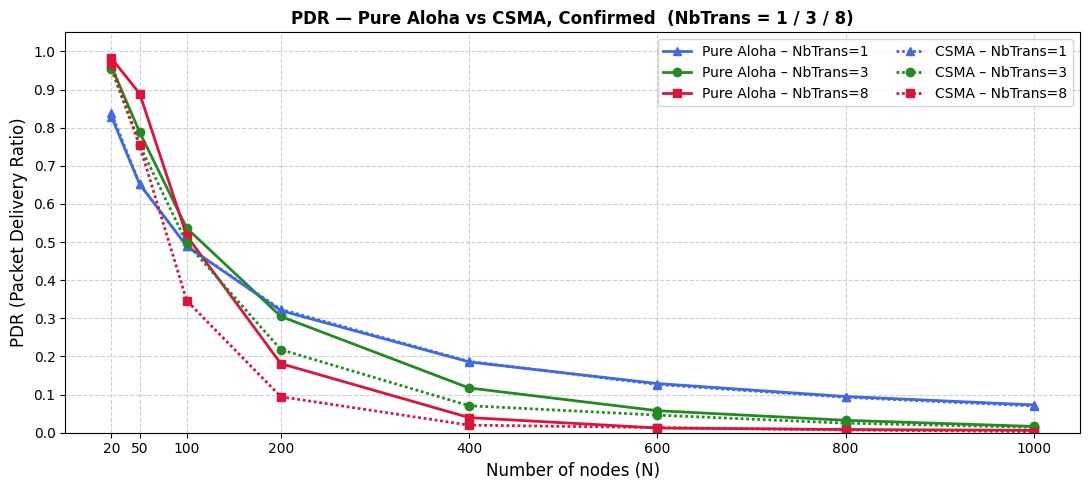

[OK] pdr_aloha_vs_csma_retx.png sauvegardé


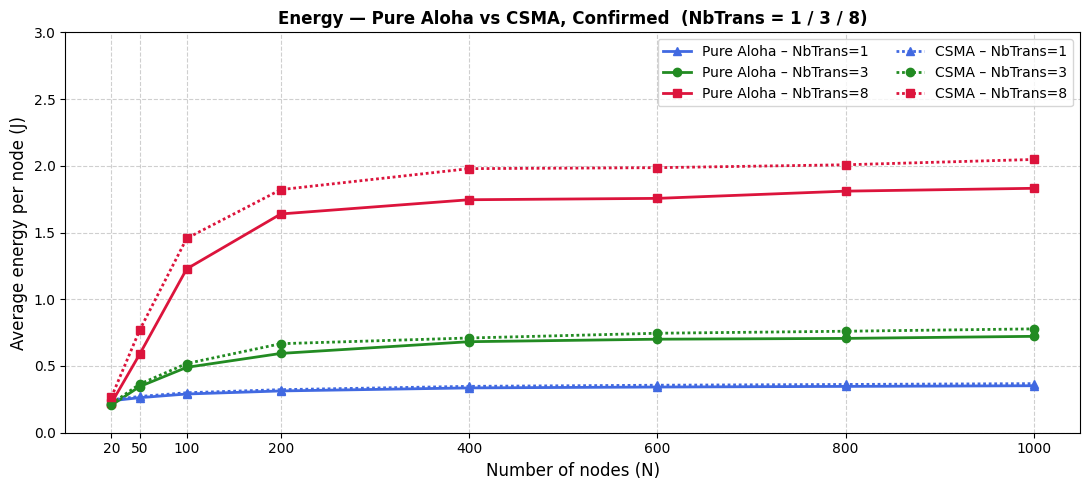

[OK] energy_aloha_vs_csma_retx.png sauvegardé


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

# ── Chemins ──────────────────────────────────────────────────────────────────
PATHS = {
    "aloha": {
        "0retx": os.path.join(BASE, "purealohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "pureAlohaAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "pureAlohaAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "0retx": os.path.join(BASE, "CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "CSMAAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "CSMAAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Helpers ───────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df

def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))

def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]].copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")

def get_pdr_confirmed(csv_path):
    ack  = get_results(csv_path, "receivedAckPackets")
    sent = get_results(csv_path, "sentPackets")
    if ack.empty or sent.empty:
        return ack
    merged = ack.merge(sent, on="N", suffixes=("_ack", "_sent"))
    out = merged[["N"]].copy()
    out["value"] = merged["value_ack"] / merged["value_sent"]
    return out

def get_energy_per_node(csv_path, with_csma_energy=False):
    df = _load(csv_path)
    N_dict = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
              df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    if sub_e.empty:
        print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                  df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})

# ── Chargement PDR ────────────────────────────────────────────────────────────
pdr = {
    "aloha_0retx": get_pdr_confirmed(PATHS["aloha"]["0retx"]),
    "aloha_2retx": get_pdr_confirmed(PATHS["aloha"]["2retx"]),
    "aloha_7retx": get_pdr_confirmed(PATHS["aloha"]["7retx"]),
    "csma_0retx":  get_pdr_confirmed(PATHS["csma"]["0retx"]),
    "csma_2retx":  get_pdr_confirmed(PATHS["csma"]["2retx"]),
    "csma_7retx":  get_pdr_confirmed(PATHS["csma"]["7retx"]),
}

# ── Chargement Énergie ────────────────────────────────────────────────────────
energy = {
    "aloha_0retx": get_energy_per_node(PATHS["aloha"]["0retx"], with_csma_energy=False),
    "aloha_2retx": get_energy_per_node(PATHS["aloha"]["2retx"], with_csma_energy=False),
    "aloha_7retx": get_energy_per_node(PATHS["aloha"]["7retx"], with_csma_energy=False),
    "csma_0retx":  get_energy_per_node(PATHS["csma"]["0retx"],  with_csma_energy=True),
    "csma_2retx":  get_energy_per_node(PATHS["csma"]["2retx"],  with_csma_energy=True),
    "csma_7retx":  get_energy_per_node(PATHS["csma"]["7retx"],  with_csma_energy=True),
}

# ── Style des courbes ─────────────────────────────────────────────────────────
#   Couleur  → protocole  : bleu=Aloha, orange=CSMA
#   Marqueur → NbTrans    : ^=1, o=3, s=8
#   Trait    → protocole  : continu=Aloha, pointillé=CSMA
CURVES = {
    # NbTrans = 1 → bleu
    "aloha_0retx": dict(color="royalblue",   marker="^", ls="-",       lw=2, label="Pure Aloha – NbTrans=1"),
    "csma_0retx":  dict(color="royalblue",   marker="^", ls=(0,(1,1)), lw=2, label="CSMA – NbTrans=1"),

    # NbTrans = 3 → vert
    "aloha_2retx": dict(color="forestgreen", marker="o", ls="-",       lw=2, label="Pure Aloha – NbTrans=3"),
    "csma_2retx":  dict(color="forestgreen", marker="o", ls=(0,(1,1)), lw=2, label="CSMA – NbTrans=3"),

    # NbTrans = 8 → rouge
    "aloha_7retx": dict(color="crimson",     marker="s", ls="-",       lw=2, label="Pure Aloha – NbTrans=8"),
    "csma_7retx":  dict(color="crimson",     marker="s", ls=(0,(1,1)), lw=2, label="CSMA – NbTrans=8"),
}

LABELS = {k: v["label"] for k, v in CURVES.items()}

# ── Affichage des valeurs ─────────────────────────────────────────────────────
def print_table(data_dict, title, unit=""):
    print(f"\n{'='*75}")
    print(f"  {title}")
    print(f"{'='*75}")
    all_N = sorted(set(
        n for df in data_dict.values()
        if df is not None and not df.empty
        for n in df["N"].tolist()
    ))
    col_w = 24
    header = f"{'N':>6}" + "".join(f"{LABELS[k]:>{col_w}}" for k in data_dict)
    print(header)
    print("-" * len(header))
    for n in all_N:
        row = f"{int(n):>6}"
        for k, df in data_dict.items():
            if df is not None and not df.empty:
                match = df[df["N"] == n]["value"]
                val = f"{match.values[0]:.4f}{' '+unit if unit else ''}" if len(match) else "—"
            else:
                val = "—"
            row += f"{val:>{col_w}}"
        print(row)
    print(f"{'='*75}\n")

def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")

    for scenario, df in data_dict.items():
        print(f"\n--- {LABELS[scenario]} ---")

        if df.empty:
            print("Aucune donnée")
            continue

        display_df = df.copy()
        display_df["value"] = display_df["value"].round(6)

        if unit:
            display_df["value"] = display_df["value"].astype(str) + f" {unit}"

        print(display_df.to_string(index=False))
print_scenario_tables(
    pdr,
    "PDR (ACK/SentPackets) — Confirmed"
)

print_scenario_tables(
    energy,
    "Énergie moyenne par nœud — Confirmed",
    unit="J"
)

# ── Figure 1 : PDR ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 5))
for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])

ax1.set_xlabel("Number of nodes (N)", fontsize=12)
ax1.set_ylabel("PDR (Packet Delivery Ratio)", fontsize=12)
ax1.set_title("PDR — Pure Aloha vs CSMA, Confirmed  (NbTrans = 1 / 3 / 8)",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=10, ncol=2)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_aloha_vs_csma_retx.png", dpi=300)
plt.show()
print("[OK] pdr_aloha_vs_csma_retx.png sauvegardé")

# ── Figure 2 : Énergie ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 5))
for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])

ax2.set_xlabel("Number of nodes (N)", fontsize=12)
ax2.set_ylabel("Average energy per node (J)", fontsize=12)
ax2.set_title("Energy — Pure Aloha vs CSMA, Confirmed  (NbTrans = 1 / 3 / 8)",
              fontsize=12, fontweight="bold")
ax2.set_ylim(bottom=0, top=3)
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=10, ncol=2)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_aloha_vs_csma_retx.png", dpi=300)
plt.show()
print("[OK] energy_aloha_vs_csma_retx.png sauvegardé")

/tmp/ipykernel_789/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_789/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_789/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_789/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_789/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_789/3468081705.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs


PDR (LoRa_NS_DER) — Unconfirmed

--- Pure Aloha – NbTrans=1 ---
   N    value
  20 0.977818
  50 0.908021
 100 0.833616
 200 0.706539
 400 0.497973
 600 0.358697
 800 0.257232
1000 0.186959

--- Pure Aloha – NbTrans=3 ---
   N    value
  20 0.991368
  50 0.968981
 100 0.911150
 200 0.771340
 400 0.472922
 600 0.269964
 800 0.154487
1000 0.090989

--- Pure Aloha – NbTrans=8 ---
   N    value
  20 0.992922
  50 0.974699
 100 0.888141
 200 0.568104
 400 0.153470
 600 0.044103
 800 0.016304
1000 0.010005

--- CSMA – NbTrans=1 ---
   N    value
  20 0.978961
  50 0.918495
 100 0.855099
 200 0.731630
 400 0.544878
 600 0.411456
 800 0.309569
1000 0.233248

--- CSMA – NbTrans=3 ---
   N    value
  20 0.994593
  50 0.975040
 100 0.924137
 200 0.822177
 400 0.551484
 600 0.354536
 800 0.228242
1000 0.154359

--- CSMA – NbTrans=8 ---
   N    value
  20 0.996723
  50 0.985056
 100 0.916960
 200 0.673120
 400 0.252133
 600 0.096943
 800 0.043486
1000 0.022392

Énergie moyenne par nœud — Unconfirm

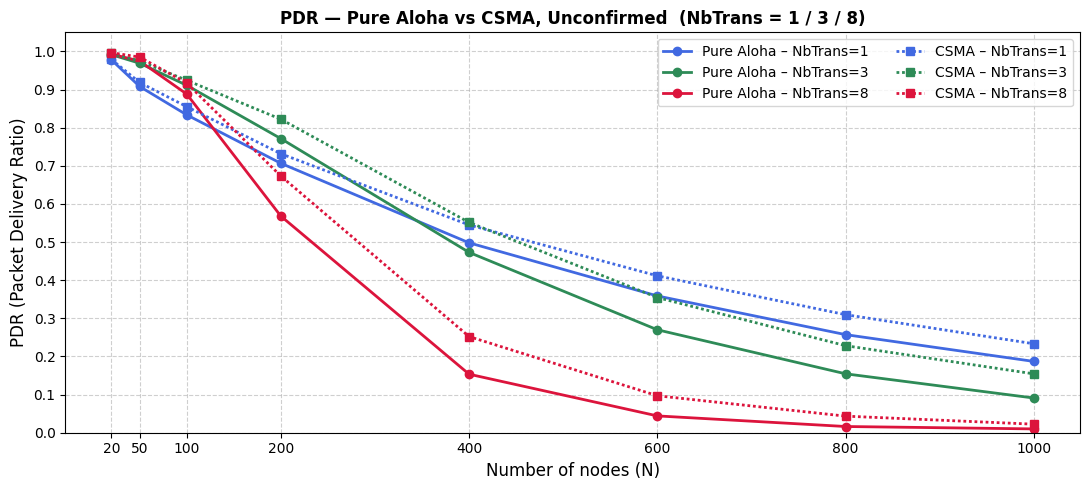

[OK] pdr_aloha_vs_csma_retx_unconf.png sauvegardé


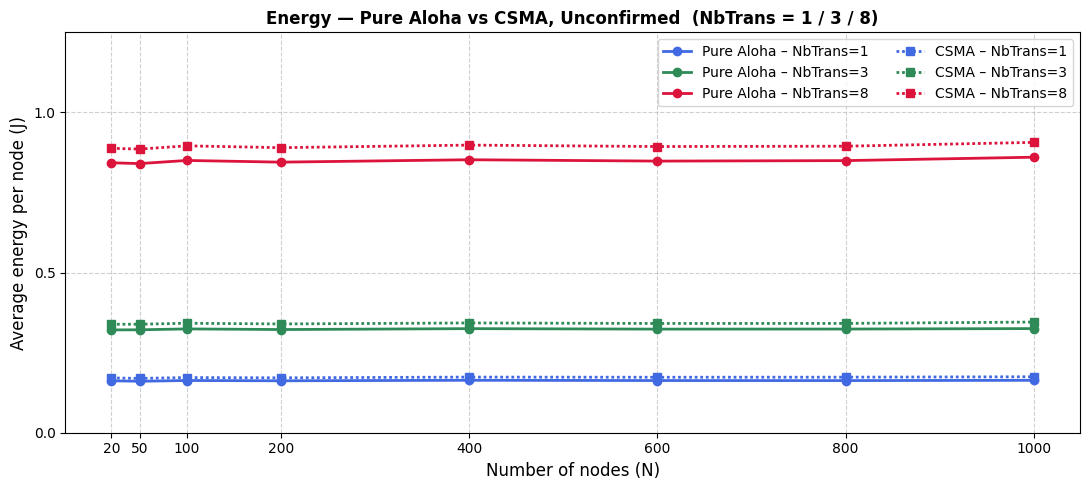

[OK] energy_aloha_vs_csma_retx_unconf.png sauvegardé


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

# ── Chemins ──────────────────────────────────────────────────────────────────
PATHS = {
    "aloha": {
        "0retx": os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "pureAlohaAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "0retx": os.path.join(BASE, "CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "CSMAAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Helpers ───────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df

def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))

def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]].copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")

def get_pdr_unconfirmed(csv_path):
    """PDR unconfirmed : LoRa_NS_DER depuis le networkServer."""
    der = get_results(csv_path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(csv_path, "LoRa_NS_DER")
    return der

def get_energy_per_node(csv_path, with_csma_energy=False):
    df = _load(csv_path)
    N_dict = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
              df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    if sub_e.empty:
        print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                  df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})

# ── Chargement PDR ────────────────────────────────────────────────────────────
pdr = {
    "aloha_0retx": get_pdr_unconfirmed(PATHS["aloha"]["0retx"]),
    "aloha_2retx": get_pdr_unconfirmed(PATHS["aloha"]["2retx"]),
    "aloha_7retx": get_pdr_unconfirmed(PATHS["aloha"]["7retx"]),
    "csma_0retx":  get_pdr_unconfirmed(PATHS["csma"]["0retx"]),
    "csma_2retx":  get_pdr_unconfirmed(PATHS["csma"]["2retx"]),
    "csma_7retx":  get_pdr_unconfirmed(PATHS["csma"]["7retx"]),
}

# ── Chargement Énergie ────────────────────────────────────────────────────────
energy = {
    "aloha_0retx": get_energy_per_node(PATHS["aloha"]["0retx"], with_csma_energy=False),
    "aloha_2retx": get_energy_per_node(PATHS["aloha"]["2retx"], with_csma_energy=False),
    "aloha_7retx": get_energy_per_node(PATHS["aloha"]["7retx"], with_csma_energy=False),
    "csma_0retx":  get_energy_per_node(PATHS["csma"]["0retx"],  with_csma_energy=True),
    "csma_2retx":  get_energy_per_node(PATHS["csma"]["2retx"],  with_csma_energy=True),
    "csma_7retx":  get_energy_per_node(PATHS["csma"]["7retx"],  with_csma_energy=True),
}

# ── Style des courbes ─────────────────────────────────────────────────────────
#   Couleur  → NbTrans   : bleu=1, orange=3, vert=8
#   Marqueur → protocole : o=Aloha, s=CSMA
#   Trait    → protocole : continu=Aloha, pointillé=CSMA
CURVES = {
    "aloha_0retx": dict(color="royalblue",   marker="o", ls="-",       lw=2, label="Pure Aloha – NbTrans=1"),
    "aloha_2retx": dict(color="seagreen",  marker="o", ls="-",       lw=2, label="Pure Aloha – NbTrans=3"),
    "aloha_7retx": dict(color="crimson",    marker="o", ls="-",       lw=2, label="Pure Aloha – NbTrans=8"),
    "csma_0retx":  dict(color="royalblue",   marker="s", ls=(0,(1,1)), lw=2, label="CSMA – NbTrans=1"),
    "csma_2retx":  dict(color="seagreen",  marker="s", ls=(0,(1,1)), lw=2, label="CSMA – NbTrans=3"),
    "csma_7retx":  dict(color="crimson",    marker="s", ls=(0,(1,1)), lw=2, label="CSMA – NbTrans=8"),
}

LABELS = {k: v["label"] for k, v in CURVES.items()}

# ── Affichage des valeurs ─────────────────────────────────────────────────────
def print_table(data_dict, title, unit=""):
    print(f"\n{'='*75}")
    print(f"  {title}")
    print(f"{'='*75}")
    all_N = sorted(set(
        n for df in data_dict.values()
        if df is not None and not df.empty
        for n in df["N"].tolist()
    ))
    col_w = 26
    header = f"{'N':>6}" + "".join(f"{LABELS[k]:>{col_w}}" for k in data_dict)
    print(header)
    print("-" * len(header))
    for n in all_N:
        row = f"{int(n):>6}"
        for k, df in data_dict.items():
            if df is not None and not df.empty:
                match = df[df["N"] == n]["value"]
                val = f"{match.values[0]:.4f}{' '+unit if unit else ''}" if len(match) else "—"
            else:
                val = "—"
            row += f"{val:>{col_w}}"
        print(row)
    print(f"{'='*75}\n")

def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")

    for scenario, df in data_dict.items():
        print(f"\n--- {LABELS[scenario]} ---")

        if df.empty:
            print("Aucune donnée")
            continue

        display_df = df.copy()
        display_df["value"] = display_df["value"].round(6)

        if unit:
            display_df["value"] = display_df["value"].astype(str) + f" {unit}"

        print(display_df.to_string(index=False))
print_scenario_tables(
    pdr,
    "PDR (LoRa_NS_DER) — Unconfirmed"
)

print_scenario_tables(
    energy,
    "Énergie moyenne par nœud — Unconfirmed",
    unit="J"
)

# ── Figure 1 : PDR ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 5))
for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])

ax1.set_xlabel("Number of nodes (N)", fontsize=12)
ax1.set_ylabel("PDR (Packet Delivery Ratio)", fontsize=12)
ax1.set_title("PDR — Pure Aloha vs CSMA, Unconfirmed  (NbTrans = 1 / 3 / 8)",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=10, ncol=2)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_aloha_vs_csma_retx_unconf.png", dpi=300)
plt.show()
print("[OK] pdr_aloha_vs_csma_retx_unconf.png sauvegardé")

# ── Figure 2 : Énergie ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 5))
for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])

ax2.set_xlabel("Number of nodes (N)", fontsize=12)
ax2.set_ylabel("Average energy per node (J)", fontsize=12)
ax2.set_title("Energy — Pure Aloha vs CSMA, Unconfirmed  (NbTrans = 1 / 3 / 8)",
              fontsize=12, fontweight="bold")
ax2.set_ylim(bottom=0, top=1.25)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=10, ncol=2)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_aloha_vs_csma_retx_unconf.png", dpi=300)
plt.show()
print("[OK] energy_aloha_vs_csma_retx_unconf.png sauvegardé")

/tmp/ipykernel_1404/2045207241.py:24: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/2045207241.py:24: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/2045207241.py:24: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/2045207241.py:24: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/2045207241.py:24: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1404/2045207241.py:24: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_

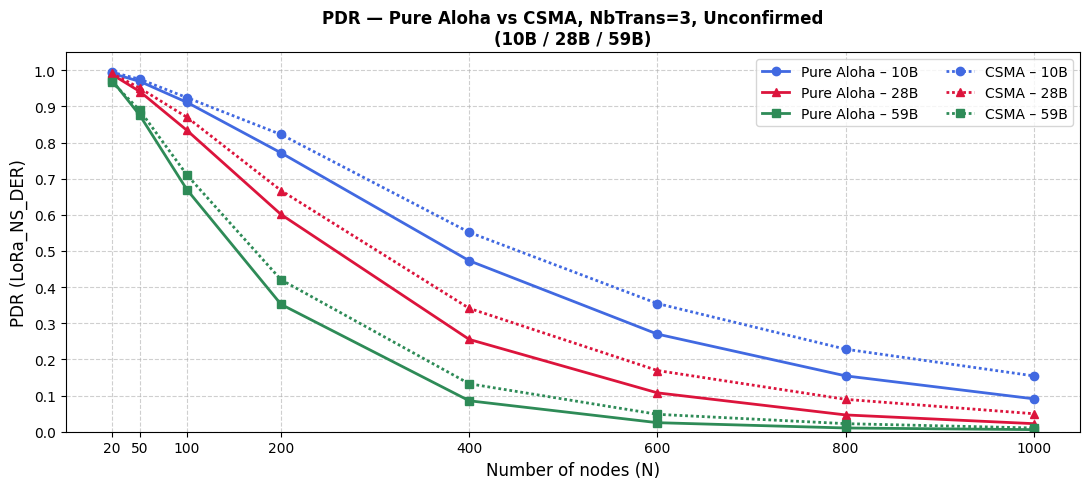

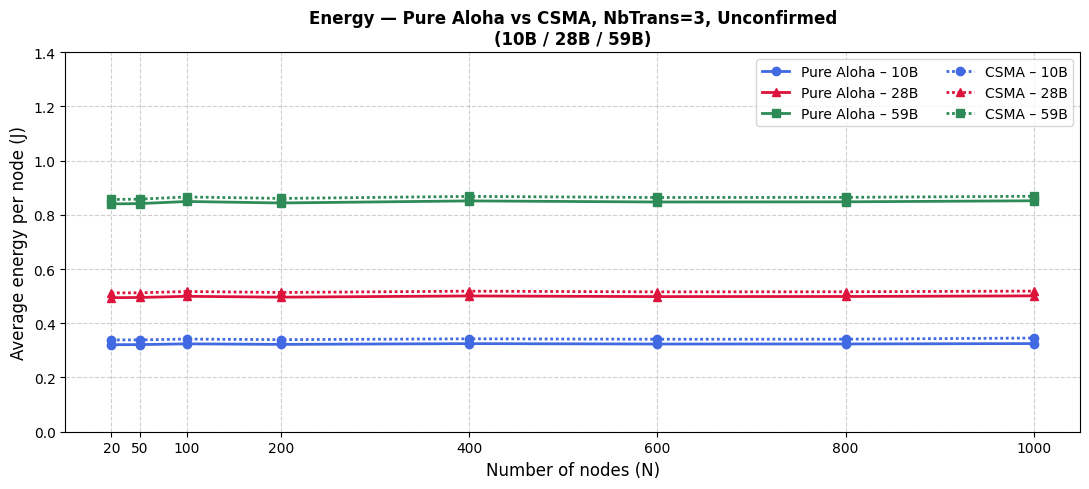

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

PATHS = {
    "aloha": {
        "10B": os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "28B": os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv"),
        "59B": os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "10B": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "28B": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv"),
        "59B": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Helpers ───────────────────────────────────────────────────────────────────
def get_results(csv_path, scalar_name, module_filter=None):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        return pd.DataFrame(columns=["N", "value"])
    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")

def get_energy_per_node(csv_path, with_csma_energy=False):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))
    mask_e = (df["name"] == "totalEnergyConsumed") & df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})
    if sub_e.empty:
        return pd.DataFrame(columns=["N", "value"])
    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if not sub_c.empty:
            sub_e = sub_e.merge(sub_c, on=["run", "module"], how="left")
            sub_e["csma_energy"] = sub_e["csma_energy"].fillna(0)
            sub_e["energy"] = sub_e["energy"] + sub_e["csma_energy"]
    sub_e["node_idx"] = sub_e["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    sub_e["N"] = sub_e["run"].map(N_dict)
    sub_e = sub_e.dropna(subset=["N", "node_idx"])
    sub_e = sub_e[sub_e["node_idx"] < sub_e["N"]]
    mean_per_run = sub_e.groupby(["run", "N"])["energy"].mean().reset_index()
    return mean_per_run.groupby("N", as_index=False)["energy"].mean().sort_values("N").rename(columns={"energy": "value"})

def load_der(path):
    der = get_results(path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(path, "LoRa_NS_DER")
    return der

# ── Chargement ────────────────────────────────────────────────────────────────
der    = {proto: {p: load_der(PATHS[proto][p])                           for p in ["10B","28B","59B"]} for proto in ["aloha","csma"]}
energy = {proto: {p: get_energy_per_node(PATHS[proto][p], proto=="csma") for p in ["10B","28B","59B"]} for proto in ["aloha","csma"]}

# ── Style visuel ──────────────────────────────────────────────────────────────
# Couleur  → payload   : bleu=10B, rouge=28B, vert=59B
# Trait    → protocole : continu=Aloha, pointillé=CSMA
# Marqueur → payload   : o=10B, ^=28B, s=59B

PAYLOAD_STYLE = {
    "10B": dict(marker="o", color="royalblue"),
    "28B": dict(marker="^", color="crimson"),
    "59B": dict(marker="s", color="seagreen"),
}
PROTO_LS    = {"aloha": "-",        "csma": (0, (1, 1))}
PROTO_LABEL = {"aloha": "Pure Aloha", "csma": "CSMA"}

# ── Figure PDR ────────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 5))

for proto in ["aloha", "csma"]:
    for payload in ["10B", "28B", "59B"]:
        df = der[proto][payload]
        if df.empty:
            continue
        s = PAYLOAD_STYLE[payload]
        ax1.plot(df["N"], df["value"],
                 color=s["color"], marker=s["marker"],
                 linestyle=PROTO_LS[proto], linewidth=2,
                 label=f"{PROTO_LABEL[proto]} – {payload}")

ax1.set_xlabel("Number of nodes (N)", fontsize=12)
ax1.set_ylabel("PDR (LoRa_NS_DER)", fontsize=12)
ax1.set_title("PDR — Pure Aloha vs CSMA, NbTrans=3, Unconfirmed\n(10B / 28B / 59B)",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=10, ncol=2)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_aloha_csma_payload.png", dpi=300)
plt.show()

# ── Figure Énergie ────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 5))

for proto in ["aloha", "csma"]:
    for payload in ["10B", "28B", "59B"]:
        df = energy[proto][payload]
        if df.empty:
            continue
        s = PAYLOAD_STYLE[payload]
        ax2.plot(df["N"], df["value"],
                 color=s["color"], marker=s["marker"],
                 linestyle=PROTO_LS[proto], linewidth=2,
                 label=f"{PROTO_LABEL[proto]} – {payload}")

ax2.set_xlabel("Number of nodes (N)", fontsize=12)
ax2.set_ylabel("Average energy per node (J)", fontsize=12)
ax2.set_title("Energy — Pure Aloha vs CSMA, NbTrans=3, Unconfirmed\n(10B / 28B / 59B)",
              fontsize=12, fontweight="bold")
ax2.set_ylim(0, 1.4)
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=10, ncol=2)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_aloha_csma_payload.png", dpi=300)
plt.show()